# BEACON SLM EXPLORATION

API Team : Abdul, Oktay

v1.0  · draft · April 19, 2026


This notebook explores the use of Small Language Models (SLMs) for detecting phishing and scam content for a potential use in Beacon API.

**Goals:**
1. Grab relevant spam/phishing datasets; Kaggle, etc...
2. Run inference using pre-trained "raw" SLMs.
3. Document it well
4. Explore ways to host this potentiallu in a dockerized environment




# Heading
##
- Bulelt

In [ ]:
!pip install -q transformers datasets setfit torch pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 859.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


# DATASETS



1. **Web Page Content**

    **Phishing Webpage Dataset (Kaggle)**

    Includes content-based features from 11,000+ websites.

    https://www.kaggle.com/datasets/shashwatwork/phishing-dataset-for-machine-learning

2. **Malicious URLs**

    **Malicious URLs (Kaggle):** Over 650,000 URLs labeled as benign, phishing, malware, or defacement.

    https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset

    **PhishTank:** A collaborative clearinghouse for data and information about phishing on the internet.

    https://www.phishtank.com/developer_info.php

    **OpenPhish:** Another high-quality feed of phishing URLs.

    https://openphish.com/

3. **Phishing & Scam Text**

    **SMS Spam Collection (UCI):** The world-standard benchmark for SMS scams.

    https://archive.ics.uci.edu/dataset/228/sms+spam+collection

    **Mendeley Smishing Dataset:** A more recent dataset specifically labeled for "smishing" (phishing via SMS).

    https://data.mendeley.com/datasets/f45bkkt8pr/1

    **Nazario Phishing Corpus:** A massive, long-running collection of actual phishing emails.

    https://monkey.org/~jose/phishing/






# LANGUAGE MODELS

1. High Speed & Low Latency

    **DistilBERT Base Uncased:** 40% smaller and 60% faster than BERT-base while retaining 97% of its performance.

    https://huggingface.co/distilbert/distilbert-base-uncased


    **TinyBERT:** Even smaller than DistilBERT. Ideal if you need to run inference on a machine with very limited CPU/RAM.

    https://huggingface.co/huawei-noah/TinyBERT_General_4L_312D

    **ModernBERT (2024/2025):** The new industry standard that replaces BERT. It is significantly faster on modern hardware and much more accurate for long-form text (like email_body).

    https://huggingface.co/answerdotai/ModernBERT-base


2. Few Shot Efficiency

    **SetFit:** Not just a model, but a framework. Use it with a small Sentence Transformer; it can achieve high accuracy with as few as 8–16 examples. *might have limitations with increased variance in patterns.

    https://github.com/huggingface/setfit

3. Reasoning & Nuances

    **Google Gemma 2 2B:** very capable for its size (2 billion parameters).

    https://huggingface.co/google/gemma-2-2b




# IMPORTS

In [ ]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

## 1. Load Datasets
We use the `datasets` library from Hugging Face to pull the SMS Spam Collection.

In [ ]:
from datasets import load_dataset

In [ ]:
#Define the dataset to load

dataset = load_dataset("sms_spam")

In [ ]:
print(f"Dataset sample: {dataset['train'][0]}")
print(f"Dataset structure: {dataset}")

Dataset sample: {'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n', 'label': 0}
Dataset structure: DatasetDict({
    train: Dataset({
        features: ['sms', 'label'],
        num_rows: 5574
    })
})


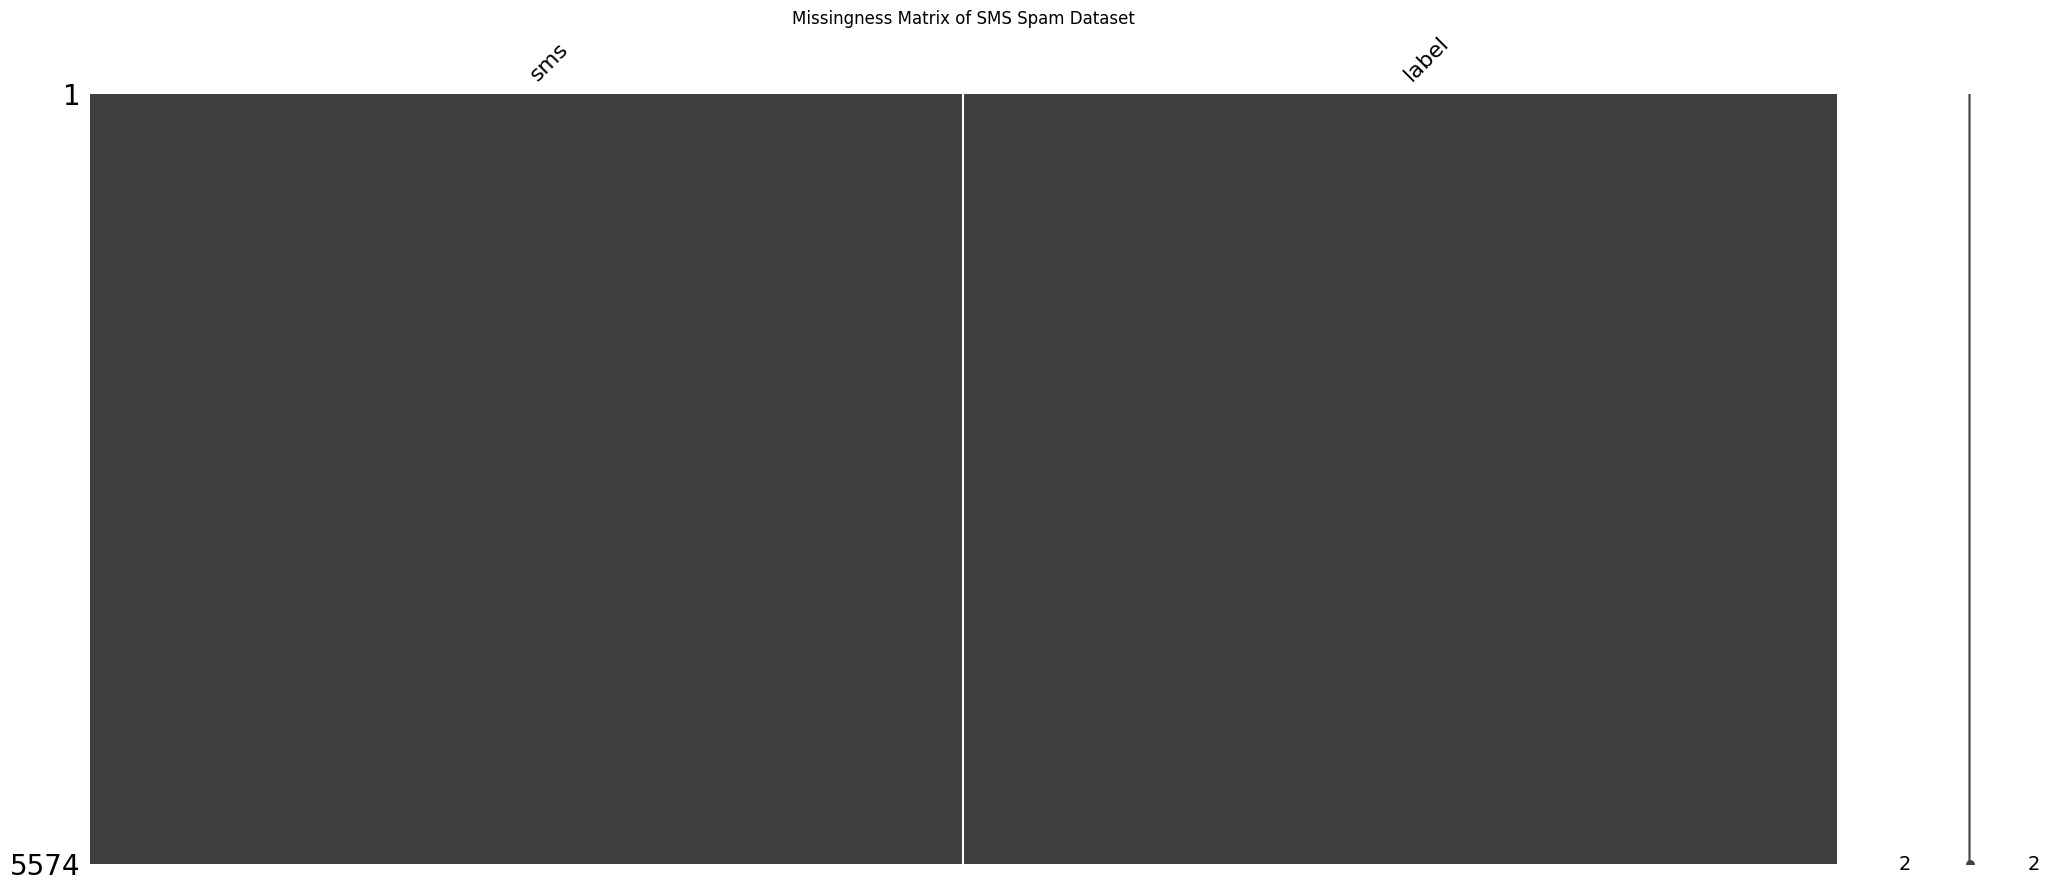

In [ ]:
# Convert the 'train' split of the dataset to a pandas DataFrame
df = dataset['train'].to_pandas()

# Generate the msno matrix
msno.matrix(df)
plt.title("Missingness Matrix of SMS Spam Dataset")
plt.show()

## 2. Raw Inference with DistilBERT
We use a pre-trained model that has already been tuned for spam detection to see its "raw" performance.

LABEL_1 : SPAM

LABEL_0 : HAM

In [ ]:
from transformers import pipeline

model_id = "mrm8488/bert-tiny-finetuned-sms-spam-detection"
classifier = pipeline("sentiment-analysis", model=model_id)

test_text = "URGENT! You have won a 1 week FREE membership to our VIP Club! Text 'WIN' to 123456 now!"
result = classifier(test_text)
print(f"Test Result: {result}")
# LABEL_1 usually maps to spam, LABEL_0 to ham.

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mrm8488/bert-tiny-finetuned-sms-spam-detection
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test Result: [{'label': 'LABEL_1', 'score': 0.8656745553016663}]


In [ ]:
test_text = "Hey, how you doing? Let's meet sometime"
result = classifier(test_text)
print(f"Test Result: {result}")


Test Result: [{'label': 'LABEL_0', 'score': 0.9382839202880859}]


In [ ]:
test_text1 = "To proceed please enter your phone number"
result = classifier(test_text1)
print(f"Test Result: {result}")

Test Result: [{'label': 'LABEL_0', 'score': 0.9266864061355591}]


In [ ]:
test_text2 = "To proceed please enter your phone number and SSN"
result = classifier(test_text2)
print(f"Test Result: {result}")

Test Result: [{'label': 'LABEL_0', 'score': 0.9175536632537842}]


In [ ]:
test_text3 = "SUBSCRIBE for 80% off your next order! TEXT to get it rn"
result = classifier(test_text3)
print(f"Test Result: {result}")

Test Result: [{'label': 'LABEL_0', 'score': 0.9012092351913452}]


## 3. SetFit Exploration
SetFit allows for efficient few-shot classification. This is ideal when we have new types of scams/phishing that we only have a few examples of.

In [ ]:
from setfit import SetFitModel

# Load a pre-trained SetFit model
model = SetFitModel.from_pretrained("sentence-transformers/paraphrase-MiniLM-L3-v2")

# In the 'training' phase (not done here per spec), we would use trainer.train()
print("SetFit model loaded successfully.")